In [48]:
# 1. Reload everything clean
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

traders = pd.read_csv("historical_data.csv")
fg = pd.read_csv("fear_greed_index.csv")

In [41]:
# 2. Clean column names
traders.columns = traders.columns.str.strip().str.lower()
fg.columns = fg.columns.str.strip().str.lower()

In [42]:
# 3. Fix date columns
traders['timestamp ist'] = pd.to_datetime(traders['timestamp ist'], errors='coerce')
traders['date'] = traders['timestamp ist'].dt.date

fg['date'] = pd.to_datetime(fg['date'], errors='coerce').dt.date

In [43]:
# 4. Clean PnL
traders = traders.dropna(subset=['closed pnl'])

In [44]:
# 5. Merge
df = pd.merge(traders, fg, on='date', how='inner')

In [45]:
# 6. CHECK columns (IMPORTANT)
print("FINAL COLUMNS:", df.columns)

FINAL COLUMNS: Index(['account', 'coin', 'execution price', 'size tokens', 'size usd', 'side',
       'timestamp ist', 'start position', 'direction', 'closed pnl',
       'transaction hash', 'order id', 'crossed', 'fee', 'trade id',
       'timestamp_x', 'date', 'timestamp_y', 'value', 'classification'],
      dtype='object')


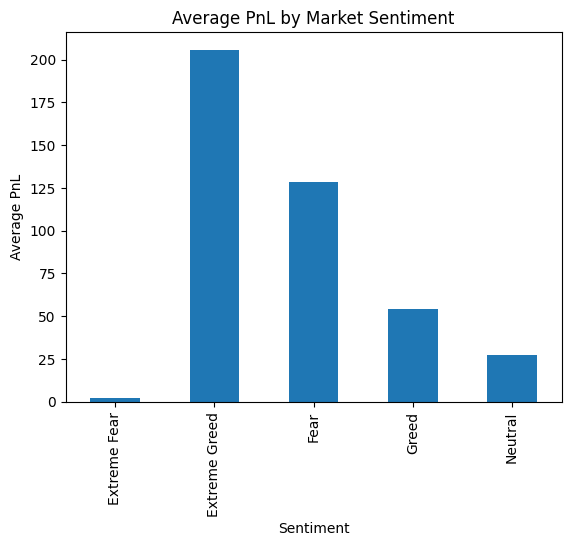

In [47]:
# 7. Plot (FINAL)
df.groupby('classification')['closed pnl'].mean().plot(kind='bar')

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average PnL")
plt.show()